In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")

Downloading bucket files: 52847336 / 52847336 complete

Downloading bytes: 52847336 / 52847336 complete

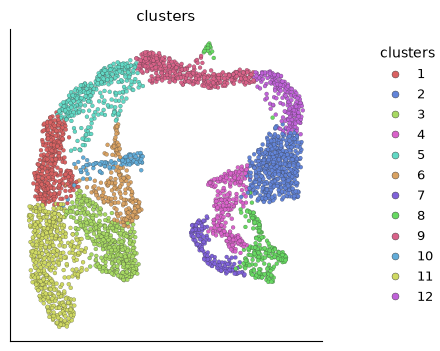

In [3]:
ds.plots.embedding(
    run=analysis_run,
    color_by="clusters",
)

In [4]:
cell_cycle_ref = ds.run_cell_cycle_scoring(analysis_run["analysis_cell_selection"])
cell_cycle_values = ds.load_artifact(cell_cycle_ref)
s_score = np.asarray(cell_cycle_values["s_score"][:])
g2m_score = np.asarray(cell_cycle_values["g2m_score"][:])
phase = np.asarray(cell_cycle_values["phase"][:]).astype(str)

In [5]:
phase_colors = {
    "G1": "grey",
    "S": "salmon",
    "G2M": "green",
}

umap = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
plt.scatter(
    umap["umap_1"],
    umap["umap_2"],
    c=[phase_colors[value] for value in phase],
    s=3,
)

In [6]:
pd.crosstab(analysis_run.cells.fetch("clusters"), phase, normalize="index")

col_0,G1,G2M,S
row_0,,,
1,0.942779,0.000000,0.057221
2,0.478516,0.001953,0.519531
3,0.958785,0.000000,0.041215
4,0.156780,0.059322,0.783898
5,0.885387,0.005731,0.108883
6,0.974874,0.000000,0.025126
7,0.000000,0.103448,0.896552
8,0.000000,0.972973,0.027027
9,0.620690,0.002653,0.376658


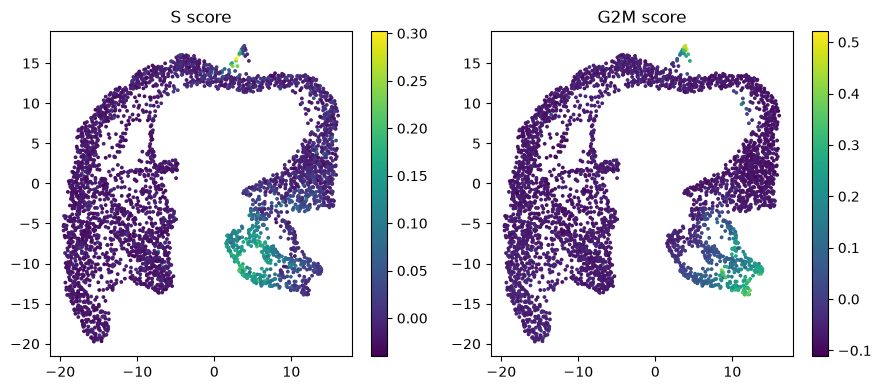

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, values, title in (
    (axes[0], s_score, "S score"),
    (axes[1], g2m_score, "G2M score"),
):
    points = axis.scatter(umap["umap_1"], umap["umap_2"], c=values, s=3)
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure

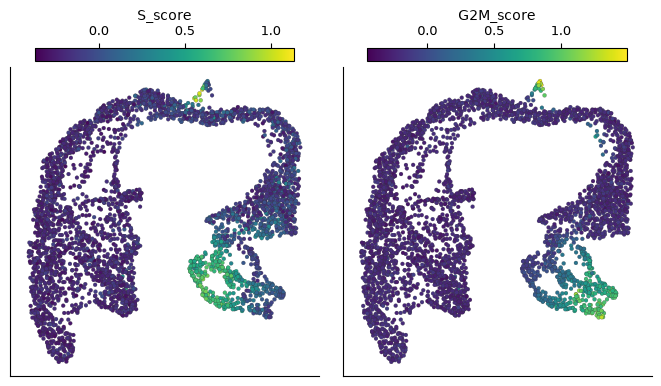

In [8]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=["S_score", "G2M_score"],
    n_columns=2,
)

In [9]:
pd.Series(
    {
        "S": np.corrcoef(s_score, ds.cells.fetch("S_score"))[0, 1],
        "G2M": np.corrcoef(g2m_score, ds.cells.fetch("G2M_score"))[0, 1],
    },
    name="Pearson r",
)

S      0.975408
G2M    0.968981
Name: Pearson r, dtype: float64